In [6]:
import numpy as np
import matplotlib.pyplot as plt

from tree.tree import Tree
from tree_tensor.tree_tensor import TreeBasedTensor
from tree_cross.tree_cross import TreeCross
from tree.tree_util import linear_tupletree, balanced_binary_tupletree, weighted_binary_tupletree
from pde.coeff_function import coeff

rng = np.random.default_rng()

In [7]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 200 # number of parameters for diffusion coeff
n_param = n_a_param
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters
tol = 1e-5
N_MC = 50

In [8]:
def RMS(x, **kwargs):
  return np.sqrt(np.mean(np.square(x), **kwargs))
  
def err_MC(tensor, cfun, N_MC=100):
  N_MC = 500
  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(tensor[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = RMS(C_eval-C_true)

  return errs

In [9]:
cfun = coeff(Nx, Ny, offset, var)

param_shape = tuple([Ny] * n_param)

# tree = Tree.from_tupletree((0,(1,((2,3), (4,(5,6))))))
# tree = Tree.from_tupletree(linear_tupletree(n_a_param))
tree = Tree.from_tupletree(balanced_binary_tupletree(n_a_param))

tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

[400] (root) 
 + [0] (dim 0)
 + [399] 
    + [199] 
    |  + [99] 
    |  |  + [49] 
    |  |  |  + [23] 
    |  |  |  |  + [11] 
    |  |  |  |  |  + [5] 
    |  |  |  |  |  |  + [1] (dim 1)
    |  |  |  |  |  |  + [4] 
    |  |  |  |  |  |     + [2] (dim 2)
    |  |  |  |  |  |     + [3] (dim 3)
    |  |  |  |  |  + [10] 
    |  |  |  |  |     + [6] (dim 4)
    |  |  |  |  |     + [9] 
    |  |  |  |  |        + [7] (dim 5)
    |  |  |  |  |        + [8] (dim 6)
    |  |  |  |  + [22] 
    |  |  |  |     + [16] 
    |  |  |  |     |  + [12] (dim 7)
    |  |  |  |     |  + [15] 
    |  |  |  |     |     + [13] (dim 8)
    |  |  |  |     |     + [14] (dim 9)
    |  |  |  |     + [21] 
    |  |  |  |        + [17] (dim 10)
    |  |  |  |        + [20] 
    |  |  |  |           + [18] (dim 11)
    |  |  |  |           + [19] (dim 12)
    |  |  |  + [48] 
    |  |  |     + [34] 
    |  |  |     |  + [28] 
    |  |  |     |  |  + [24] (dim 13)
    |  |  |     |  |  + [27] 
    |  |  |     

In [10]:
res = {}
C_a_test = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
for kickrank in [4]:
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
  res[kickrank] = {'n_eval':[], 'err':[]}
  n_eval_over_iter = []
  cross = TreeCross(C_a)
  iter = 0
  while cross.n_eval < 5e7 and iter < 20:
    cross.run(cfun, n_iter=1, eps=tol, kickrank=kickrank, verbose=1)
    # C_a.print()

    C_a_test = C_a.copy()
    C_a_test.round(tol=tol)
    # C_a_test.print()
    errs = err_MC(C_a_test, cfun)

    res[kickrank]['err'] += [RMS(errs)]
    res[kickrank]['n_eval'] += [cross.n_eval]
    iter += 1

C_a_test.print()

swp: 1/1 f_evals=38360 self.max_dx=2.91e+84
swp: 1/1 f_evals=99352 self.max_dx=7.80e+00
swp: 1/1 f_evals=198194 self.max_dx=4.74e+00
swp: 1/1 f_evals=367276 self.max_dx=6.19e+00
swp: 1/1 f_evals=658928 self.max_dx=5.27e+00
swp: 1/1 f_evals=1059985 self.max_dx=3.18e+00
swp: 1/1 f_evals=1626352 self.max_dx=1.35e+00
swp: 1/1 f_evals=2431398 self.max_dx=6.32e-01
swp: 1/1 f_evals=3614499 self.max_dx=6.27e-01
swp: 1/1 f_evals=5287649 self.max_dx=1.02e-01
swp: 1/1 f_evals=7436942 self.max_dx=7.93e-02
swp: 1/1 f_evals=10167098 self.max_dx=2.10e-02
swp: 1/1 f_evals=13530685 self.max_dx=2.45e-02
swp: 1/1 f_evals=17347253 self.max_dx=1.46e-02
swp: 1/1 f_evals=21574412 self.max_dx=7.71e-03
swp: 1/1 f_evals=26089358 self.max_dx=2.82e-03
swp: 1/1 f_evals=30808389 self.max_dx=4.28e-04
swp: 1/1 f_evals=35567475 self.max_dx=1.01e-04
swp: 1/1 f_evals=40353353 self.max_dx=9.46e-05
swp: 1/1 f_evals=45174265 self.max_dx=8.20e-05
Tree tensor with shape (100, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

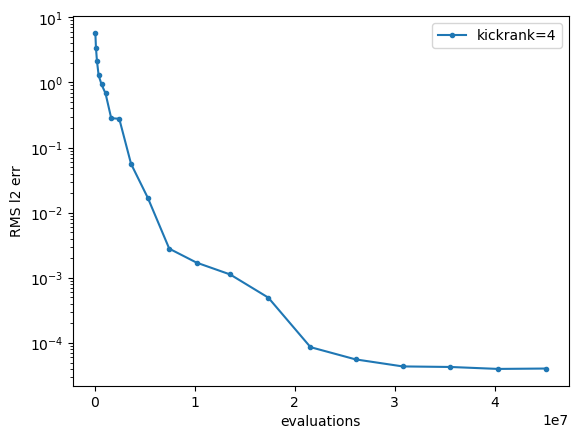

In [11]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['n_eval'], data['err'], marker='o', ms=3, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('evaluations')
ax.legend()

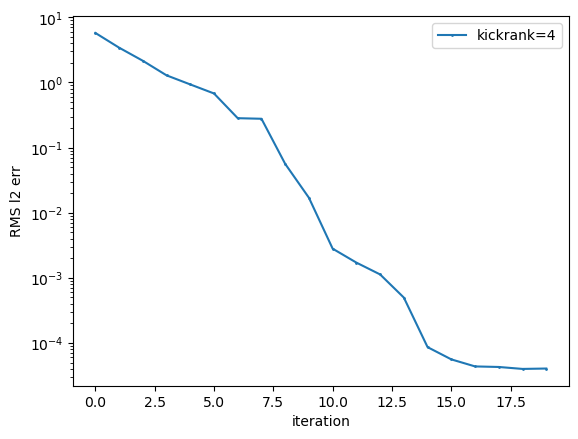

In [12]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('iteration')
ax.legend()

RMS l2 err = 3.90e-05


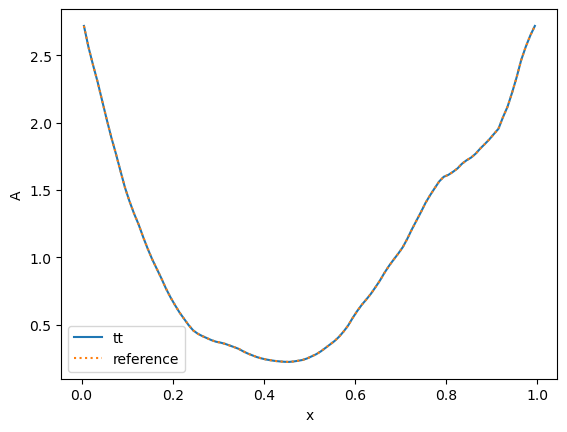

In [14]:
errs = err_MC(C_a_test, cfun, N_MC=N_MC)

print(f'RMS l2 err = {RMS(errs):.2e}')

fig, ax = plt.subplots()
y = rng.integers(0, Ny, n_a_param)
C_eval = np.ravel(C_a[:, *y])
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
C_true = cfun(X)

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [ ]:
niter = 15
eps = 1e-4
kickrank = 5
runs = 3

res = {}

trees = {
  'linear': Tree.from_tupletree(linear_tupletree(n_param)),
  'balanced': Tree.from_tupletree(balanced_binary_tupletree(n_param)),
  'weighted': Tree.from_tupletree(weighted_binary_tupletree(n_param, (np.arange(n_param)+1)**-2.))
}

: 

In [ ]:
for tree_type, tree in trees.items():
  print('type: ', tree_type)
  stats = {'errs':[], 'sizes':[], 'evals':[]}
  for run in range(runs):
    print(f'\r run {run}', end='')
    C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
    errs = np.zeros(niter)
    evals = np.zeros(niter)
    sizes = np.zeros(niter)
    cross = TreeCross(C_a)
    for iter in range(niter):
      cross.run(cfun, n_iter=1, eps=eps, kickrank=kickrank, verbose=False, force_init=False)
      C_test = TreeBasedTensor(C_a)
      C_test.round(tol=tol)
      errs[iter] = np.sqrt(np.mean(np.square(err_MC(C_test, cfun, N_MC=N_MC))))
      evals[iter] = cross.n_eval
      sizes[iter] = C_test.sparse_size

    stats['errs'] += [errs]
    stats['evals'] += [evals]
    stats['sizes'] += [sizes]
  print()

  res[tree_type] = stats

type:  linear
 run 2
type:  balanced
 run 2

In [ ]:
weights = (np.arange(n_param)+1)**-2.

tree = Tree.from_tupletree(weighted_binary_tupletree(n_param, weights))

stats = {'errs':[], 'sizes':[], 'evals':[]}
for run in range(runs):
  print(f'\r run {run}', end='')
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
  errs = np.zeros(niter)
  evals = np.zeros(niter)
  sizes = np.zeros(niter)
  cross = TreeCross(C_a)
  for iter in range(niter):
    cross.run(cfun, n_iter=1, eps=eps, kickrank=kickrank, verbose=False, force_init=False)
    C_test = TreeBasedTensor(C_a)
    C_test.round(tol=tol)
    errs[iter] = np.sqrt(np.mean(np.square(err_MC(C_test, cfun, N_MC=N_MC))))
    evals[iter] = cross.n_eval
    sizes[iter] = C_test.sparse_size

  stats['errs'] += [errs]
  stats['evals'] += [evals]
  stats['sizes'] += [sizes]

res['weighted'] = stats

 run 2

In [ ]:
tree = Tree.from_tupletree(balanced_binary_tupletree(n_param))

stats = {'errs':[], 'sizes':[], 'evals':[]}
for run in range(runs):
  print(f'\r run {run}', end='')
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
  errs = np.zeros(niter)
  evals = np.zeros(niter)
  sizes = np.zeros(niter)
  cross = TreeCross(C_a)
  for iter in range(niter):
    cross.run(cfun, n_iter=1, eps=eps, kickrank=kickrank, verbose=False, force_init=False)
    C_test = TreeBasedTensor(C_a)
    C_test.round(tol=tol)
    errs[iter] = np.sqrt(np.mean(np.square(err_MC(C_test, cfun, N_MC=N_MC))))
    evals[iter] = cross.n_eval
    sizes[iter] = C_test.sparse_size

  stats['errs'] += [errs]
  stats['evals'] += [evals]
  stats['sizes'] += [sizes]

res['balanced'] = stats

 run 2

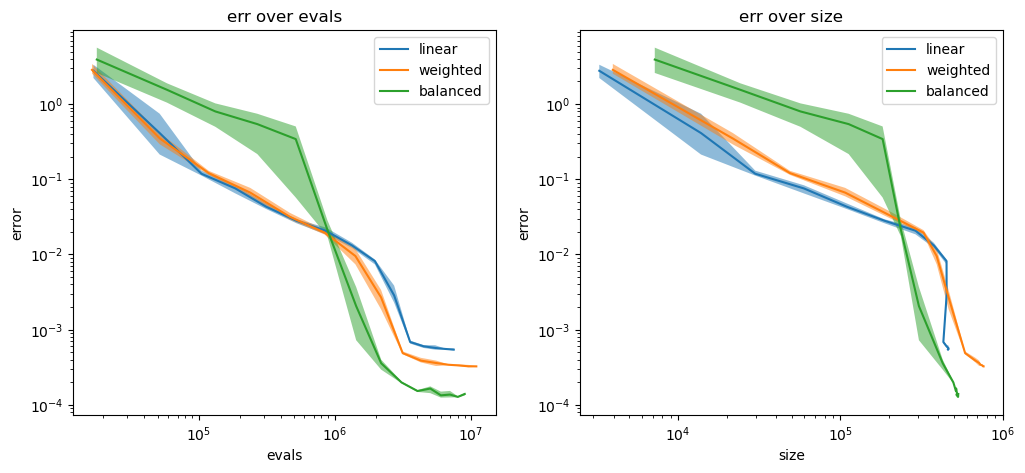

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].set_title('err over evals')
axs[0].set_xlabel('evals')
axs[1].set_title('err over size')
axs[1].set_xlabel('size')
for tree_type in ['linear', 'weighted', 'balanced']:
  evals = np.array(res[tree_type]['evals'])
  sizes = np.array(res[tree_type]['sizes'])
  errs = np.array(res[tree_type]['errs'])
  axs[0].plot(np.mean(evals, axis=0), np.mean(errs, axis=0), label=tree_type)
  axs[0].fill_between(np.mean(evals, axis=0), np.min(errs, axis=0), np.max(errs, axis=0), alpha=.5)
  axs[1].plot(np.mean(sizes, axis=0), np.mean(errs, axis=0), label=tree_type)
  axs[1].fill_between(np.mean(sizes, axis=0), np.min(errs, axis=0), np.max(errs, axis=0), alpha=.5)

for ax in axs:
  ax.legend()
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_ylabel('error')